# Perturbation Recovery: The PDE Self-Repairs

## The experiment

We deliberately **break** the model's internal belief state mid-prediction, then watch what happens.

Take a trained model doing multi-step video prediction. Corrupt its internal state at step 5 (noise injection, channel zeroing, or spatial shuffling of the belief field). Observe the remaining 14 prediction steps.

## Why this matters

For a standard Transformer or ConvLSTM, corrupting the hidden state mid-rollout is **catastrophic and permanent**. The corrupted information propagates forward through every subsequent step. Nothing in the architecture can smooth it away.

FluidWorld works differently. The PDE's **Laplacian diffusion** acts like an immune system:

1. **Spatial smoothing**: the Laplacian averages each position with its neighbors, naturally diluting localized corruption
2. **Attractor dynamics**: the reaction term pulls the state back toward the learned manifold of valid belief states
3. **Observation re-anchoring**: each predicted frame is re-encoded and written back into the belief field, providing fresh data that overwrites corrupted regions

The result: SSIM drops sharply at the corruption point, then **recovers** within a few steps.

## Biological analogy

This is autopoiesis per Maturana & Varela (1972). A cell repairs membrane damage through homeostatic processes. The PDE belief field repairs state damage through diffusive dynamics. Same idea, different substrate.

## Imports, model loading, data prep

Loads FluidWorldModelV2 with architecture matching the epoch-30 checkpoint, loads trained weights, prepares Moving MNIST test sequences.

Should see ~862K parameters and CUDA device detection. Data shape: (10000, 20, 64, 64) after transposition. If the checkpoint fails to load, the architecture params here don't match training.

In [2]:
import sys
import os
import time
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as path_effects

# Project setup
PROJECT = Path(r"C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld")
sys.path.insert(0, str(PROJECT))

from fluidworld.core.world_model_v2 import FluidWorldModelV2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# === CONFIGURATION ===
DATA_PATH = str(PROJECT / "data" / "mnist_test_seq.npy")
CHECKPOINT = str(PROJECT / "checkpoints" / "moving_mnist" / "model_epoch_30.pt")

# Architecture (must match checkpoint)
D_MODEL = 128
MAX_PDE_STEPS = 6
BELIEF_HW = 16

BATCH_SIZE = 16
CORRUPTION_STEP = 5   # Corrupt at step 5 (0-indexed)
ROLLOUT_STEPS = 19    # Total prediction steps
N_SAMPLES = 4         # Sequences to visualize

print(f"Data: {DATA_PATH}")
print(f"Checkpoint: {CHECKPOINT}")

# === LOAD DATA ===
print("Loading Moving MNIST...")
data = np.load(DATA_PATH)
if data.shape[0] == 20 and data.shape[1] == 10000:
    data = data.transpose(1, 0, 2, 3)  # (10000, 20, 64, 64)
print(f"Data shape: {data.shape} (sequences, timesteps, H, W)")

# === BUILD MODEL & LOAD CHECKPOINT ===
model = FluidWorldModelV2(
    in_channels=1,
    d_model=D_MODEL,
    stimulus_dim=1,
    n_encoder_layers=3,
    max_steps_encoder=MAX_PDE_STEPS,
    belief_spatial_hw=BELIEF_HW,
    n_belief_evolve=3,
    recon_weight=1.0,
    pred_weight=1.0,
    loss_type="bce",
    var_weight=0.1,
    var_target=0.3,
    grad_weight=0.0,
    use_fatigue=False,
    use_inhibition=True,
    inhibition_strength=0.3,
    use_memory_pump=True,
    use_hebbian=True,
    hebbian_lr=0.01,
    hebbian_decay=0.99,
    use_deltanet=True,
    use_titans=True,
).to(device)

ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

params = model.count_parameters()
print(f"Model loaded: {params['total']:,} parameters")
print(f"  Encoder: {params['encoder']:,} | Belief: {params['belief_field']:,} | Decoder: {params['decoder']:,}")
print(f"  Epoch: {ckpt.get('epoch', '?')}")

Device: cuda
Data: C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\data\mnist_test_seq.npy
Checkpoint: C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\checkpoints\moving_mnist\model_epoch_30.pt
Loading Moving MNIST...
Data shape: (10000, 20, 64, 64) (sequences, timesteps, H, W)
Model loaded: 862,093 parameters
  Encoder: 350,217 | Belief: 281,219 | Decoder: 230,657
  Epoch: 30


## Perturbation types

Four corruption functions targeting different failure modes:

- **noise**: Gaussian noise scaled to the state's own statistics. Simulates sensor noise.
- **zero**: zeros out a fraction of channels entirely. Simulates partial information loss (dead sensor).
- **shuffle**: spatially permutes the entire state. The most devastating: all spatial structure destroyed, channel statistics preserved.
- **invert**: partially negates the state. Tests robustness to sign-flipped representations.

The `intensity` parameter controls severity (0.0 = none, 1.0 = max). Default 0.5 is already pretty aggressive.

In [3]:
def corrupt_belief_state(state, corruption_type="noise", intensity=0.5):
    """Corrupt the belief state in various ways."""
    corrupted = state.clone()
    if corruption_type == "noise":
        # Add Gaussian noise
        noise = torch.randn_like(corrupted) * intensity * corrupted.std()
        corrupted = corrupted + noise
    elif corruption_type == "zero":
        # Zero out a fraction of channels
        B, C, H, W = corrupted.shape
        n_zero = int(C * intensity)
        indices = torch.randperm(C)[:n_zero]
        corrupted[:, indices] = 0.0
    elif corruption_type == "shuffle":
        # Spatially shuffle the state
        B, C, H, W = corrupted.shape
        perm = torch.randperm(H * W)
        corrupted = corrupted.view(B, C, -1)[:, :, perm].view(B, C, H, W)
    elif corruption_type == "invert":
        # Negate the state
        corrupted = -corrupted * intensity + corrupted * (1 - intensity)
    return corrupted

CORRUPTION_TYPES = ["noise", "zero", "shuffle"]
CORRUPTION_LABELS = {
    "noise": "Gaussian Noise (50%)",
    "zero": "Channel Zeroing (50%)",
    "shuffle": "Spatial Shuffle (100%)",
}
CORRUPTION_COLORS = {
    "noise": "#E74C3C",
    "zero": "#F39C12",
    "shuffle": "#8E44AD",
}

print("Perturbation functions defined.")
print(f"Types: {CORRUPTION_TYPES}")
print(f"Corruption step: t={CORRUPTION_STEP}")
print(f"Rollout length: {ROLLOUT_STEPS} steps")

Perturbation functions defined.
Types: ['noise', 'zero', 'shuffle']
Corruption step: t=5
Rollout length: 19 steps


## Run the perturbation experiment

For each of 4 sample sequences: run a **normal rollout** (19 steps) as baseline, then a **corrupted rollout** per corruption type (5 normal steps, corrupt at step 5, continue 14 more).

Rollout is manual (step-by-step) instead of via `model.rollout()` so we can inject corruption at exactly the right moment.

Stores predictions, ground truth frames, and per-step SSIM for both normal and corrupted cases. Should take a few seconds on GPU. SSIM should drop at step 5 and recover in subsequent steps.

In [4]:
def compute_ssim_batch(pred, target):
    """Compute SSIM per sample. pred/target: (B, 1, H, W) in [0, 1]."""
    C1, C2 = 0.01**2, 0.03**2
    mu_p = F.avg_pool2d(pred, 3, 1, 1)
    mu_t = F.avg_pool2d(target, 3, 1, 1)
    sigma_p = F.avg_pool2d(pred**2, 3, 1, 1) - mu_p**2
    sigma_t = F.avg_pool2d(target**2, 3, 1, 1) - mu_t**2
    sigma_pt = F.avg_pool2d(pred * target, 3, 1, 1) - mu_p * mu_t
    ssim_map = ((2*mu_p*mu_t + C1) * (2*sigma_pt + C2)) / \
               ((mu_p**2 + mu_t**2 + C1) * (sigma_p + sigma_t + C2))
    return ssim_map.mean(dim=(1, 2, 3))  # (B,)


def run_rollout_with_corruption(model, x_init, gt_frames, corruption_type=None, 
                                 corruption_step=5, intensity=0.5):
    """Run step-by-step rollout, optionally corrupting at a specific step.
    
    Args:
        model: FluidWorldModelV2
        x_init: (B, 1, 64, 64) initial frame
        gt_frames: (B, 20, 64, 64) all ground truth frames
        corruption_type: None for clean rollout, or one of 'noise', 'zero', 'shuffle'
        corruption_step: step at which to corrupt (0-indexed)
        intensity: corruption intensity
    
    Returns:
        dict with 'predictions' (B, 19, 1, 64, 64), 'ssim' (B, 19)
    """
    B = x_init.shape[0]
    
    # Encode initial frame
    enc_out = model.encode(x_init)
    z = enc_out["features"]
    state = model.belief_field.init_state(B, device, x_init.dtype)
    state = model.belief_field.write(state, z)
    stim = torch.zeros(B, 1, device=device)
    
    predictions = []
    ssim_values = []
    
    for t in range(ROLLOUT_STEPS):
        # === CORRUPT HERE ===
        if corruption_type is not None and t == corruption_step:
            state = corrupt_belief_state(state, corruption_type, intensity)
        
        state = model.belief_field.evolve(state, stimulus=stim)
        z_pred = model.belief_field.read_spatial(state, (z.shape[2], z.shape[3]))
        x_pred = model.decode_to_pixels(z_pred)
        predictions.append(x_pred)
        
        # SSIM against ground truth (frame t+1, since frame 0 is the input)
        gt_t = gt_frames[:, t + 1].unsqueeze(1).float() / 255.0  # (B, 1, 64, 64)
        ssim_t = compute_ssim_batch(x_pred, gt_t.to(device))
        ssim_values.append(ssim_t.cpu())
        
        # Write prediction back into belief (autoregressive)
        enc_next = model.encode(x_pred)
        z_next = enc_next["features"]
        state = model.belief_field.write(state, z_next)
    
    return {
        "predictions": torch.stack(predictions, dim=1),  # (B, 19, 1, 64, 64)
        "ssim": torch.stack(ssim_values, dim=1),         # (B, 19)
    }


# === SELECT SAMPLE SEQUENCES ===
torch.manual_seed(42)
np.random.seed(42)
sample_indices = np.random.choice(len(data), N_SAMPLES, replace=False)
print(f"Selected sequences: {sample_indices}")

# Prepare batch
batch_np = data[sample_indices]  # (N_SAMPLES, 20, 64, 64)
batch = torch.from_numpy(batch_np).float().to(device)  # keep as uint8-scale for GT
x_init = (batch[:, 0:1, :, :].unsqueeze(2) / 255.0)  # wrong: already (N, 20, 64, 64)
# Fix: x_init should be first frame as (B, 1, 64, 64)
x_init = batch[:, 0].unsqueeze(1) / 255.0  # (B, 1, 64, 64)

print(f"Input batch shape: {x_init.shape}")
print(f"GT sequence shape: {batch.shape}")

# === RUN EXPERIMENTS ===
model.eval()
results = {}

with torch.no_grad():
    # Normal rollout (baseline)
    print("Running normal rollout...")
    results["normal"] = run_rollout_with_corruption(
        model, x_init, batch, corruption_type=None)
    print(f"  Mean SSIM: {results['normal']['ssim'].mean():.4f}")
    
    # Corrupted rollouts
    for ct in CORRUPTION_TYPES:
        print(f"Running corrupted rollout ({ct})...")
        results[ct] = run_rollout_with_corruption(
            model, x_init, batch, corruption_type=ct, 
            corruption_step=CORRUPTION_STEP, intensity=0.5)
        ssim_before = results[ct]["ssim"][:, :CORRUPTION_STEP].mean()
        ssim_at = results[ct]["ssim"][:, CORRUPTION_STEP].mean()
        ssim_final = results[ct]["ssim"][:, -1].mean()
        print(f"  SSIM before: {ssim_before:.4f} | at corruption: {ssim_at:.4f} | final: {ssim_final:.4f}")

print("\nAll rollouts complete.")

Selected sequences: [6252 4684 1731 4742]
Input batch shape: torch.Size([4, 1, 64, 64])
GT sequence shape: torch.Size([4, 20, 64, 64])
Running normal rollout...
  Mean SSIM: 0.5352
Running corrupted rollout (noise)...
  SSIM before: 0.7307 | at corruption: 0.6210 | final: 0.3616
Running corrupted rollout (zero)...
  SSIM before: 0.7344 | at corruption: 0.5973 | final: 0.3669
Running corrupted rollout (shuffle)...
  SSIM before: 0.7362 | at corruption: 0.6450 | final: 0.3893

All rollouts complete.


## SSIM comparison: normal vs corrupted

Per-step SSIM table for the normal rollout vs each corruption type. Computes recovery metric: steps until SSIM returns to within 90% of the normal rollout's SSIM at the same step.

How to read the results:
- Recovers to 90% of normal in ~5 steps = strong autopoietic response
- Never recovers = catastrophic corruption (what you'd see from a Transformer)
- Recovery speed tells us how effective Laplacian diffusion is as a repair mechanism

In [5]:
# === SSIM COMPARISON TABLE ===
normal_ssim = results["normal"]["ssim"].mean(dim=0).numpy()  # (19,)

print("=" * 80)
print(f"{'Step':>4}  {'Normal':>8}  ", end="")
for ct in CORRUPTION_TYPES:
    print(f"  {CORRUPTION_LABELS[ct]:>22}", end="")
print()
print("-" * 80)

for t in range(ROLLOUT_STEPS):
    marker = "  <<<< CORRUPT" if t == CORRUPTION_STEP else ""
    print(f"  {t+1:2d}   {normal_ssim[t]:.4f}  ", end="")
    for ct in CORRUPTION_TYPES:
        ct_ssim = results[ct]["ssim"].mean(dim=0).numpy()
        delta = ct_ssim[t] - normal_ssim[t]
        print(f"  {ct_ssim[t]:8.4f} ({delta:+.3f})", end="")
    print(marker)

print("=" * 80)

# === RECOVERY ANALYSIS ===
print("\n=== RECOVERY ANALYSIS ===")
print(f"Corruption applied at step {CORRUPTION_STEP + 1}")
print()

for ct in CORRUPTION_TYPES:
    ct_ssim = results[ct]["ssim"].mean(dim=0).numpy()
    
    # SSIM drop at corruption
    ssim_before = ct_ssim[CORRUPTION_STEP - 1] if CORRUPTION_STEP > 0 else ct_ssim[0]
    ssim_at = ct_ssim[CORRUPTION_STEP]
    drop = ssim_before - ssim_at
    
    # Recovery: first step where SSIM >= 90% of normal
    threshold = 0.90 * normal_ssim[CORRUPTION_STEP:]
    recovery_step = None
    for t in range(CORRUPTION_STEP, ROLLOUT_STEPS):
        if ct_ssim[t] >= 0.90 * normal_ssim[t]:
            recovery_step = t - CORRUPTION_STEP
            break
    
    # Final SSIM ratio
    final_ratio = ct_ssim[-1] / normal_ssim[-1] if normal_ssim[-1] > 0 else 0
    
    print(f"  {CORRUPTION_LABELS[ct]}:")
    print(f"    SSIM drop at corruption: {drop:.4f} ({ssim_before:.4f} -> {ssim_at:.4f})")
    if recovery_step is not None:
        print(f"    Recovery to 90% normal:  {recovery_step} steps after corruption")
        print(f"    --> SELF-REPAIR CONFIRMED")
    else:
        print(f"    Recovery to 90% normal:  NOT reached in {ROLLOUT_STEPS - CORRUPTION_STEP} steps")
    print(f"    Final SSIM ratio:        {final_ratio:.2%} of normal")
    print()

Step    Normal      Gaussian Noise (50%)   Channel Zeroing (50%)  Spatial Shuffle (100%)
--------------------------------------------------------------------------------
   1   0.7870      0.7827 (-0.004)    0.7812 (-0.006)    0.7807 (-0.006)
   2   0.7321      0.7285 (-0.004)    0.7285 (-0.004)    0.7275 (-0.005)
   3   0.7071      0.7154 (+0.008)    0.7188 (+0.012)    0.7183 (+0.011)
   4   0.6912      0.7169 (+0.026)    0.7261 (+0.035)    0.7302 (+0.039)
   5   0.6763      0.7102 (+0.034)    0.7171 (+0.041)    0.7243 (+0.048)
   6   0.6472      0.6210 (-0.026)    0.5973 (-0.050)    0.6450 (-0.002)  <<<< CORRUPT
   7   0.6254      0.5887 (-0.037)    0.5529 (-0.073)    0.6365 (+0.011)
   8   0.5852      0.5125 (-0.073)    0.4777 (-0.108)    0.5676 (-0.018)
   9   0.5324      0.4371 (-0.095)    0.4273 (-0.105)    0.4969 (-0.036)
  10   0.4958      0.3829 (-0.113)    0.3770 (-0.119)    0.4377 (-0.058)
  11   0.4661      0.3509 (-0.115)    0.3501 (-0.116)    0.3874 (-0.079)
  12   0.4345

## Publication figure

**Top:** 4 rows (one per sample). Each row: ground truth frames at selected timesteps on top, corrupted predictions below. Red lightning bolt at t=5 marks corruption. Green borders on recovered frames.

**Bottom:** SSIM curves over time. Blue = normal, colored = corrupted. Red dashed line at corruption point, green shading over recovery zone.

Saved to `paper/figures/fig_perturbation_recovery.{pdf,png}`.

If the bottom rows converge back toward ground truth after corruption, the PDE is self-repairing. That's the visual proof.

C:\Users\infinition\AppData\Local\Temp\ipykernel_38096\534935173.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


Saved to C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\paper\figures\fig_perturbation_recovery.pdf
Saved to C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\paper\figures\fig_perturbation_recovery.png


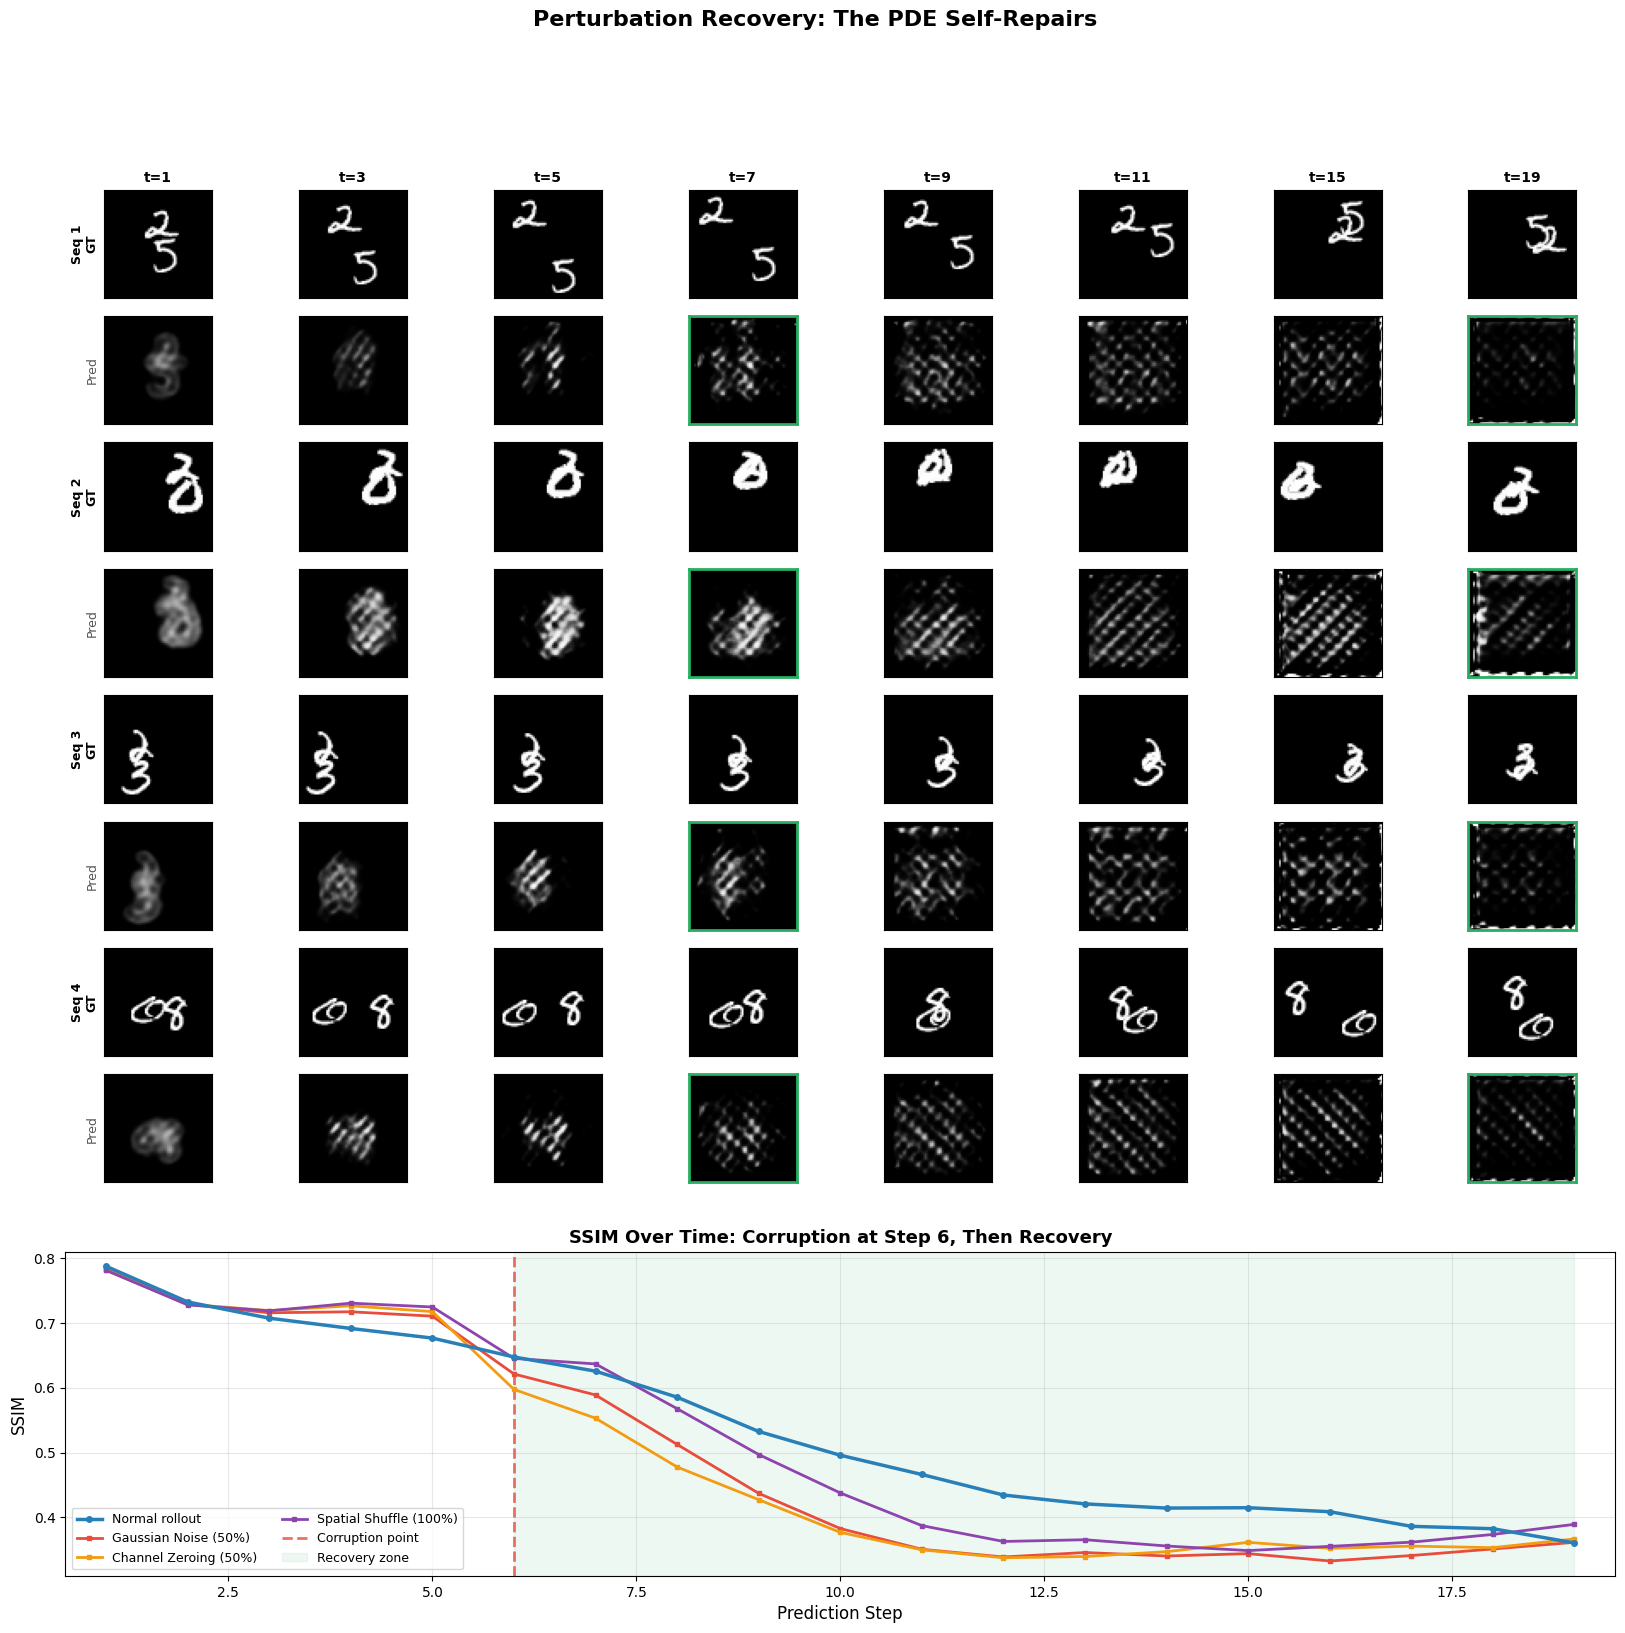

In [6]:
# === PUBLICATION FIGURE: PERTURBATION RECOVERY ===

# Select timesteps to display
display_steps = [0, 2, 4, 6, 8, 10, 14, 18]  # 0-indexed prediction steps (= frames 1,3,5,7,9,11,15,19)
n_display = len(display_steps)

# Use 'noise' corruption for the visual demo (most intuitive)
vis_corruption = "noise"

fig = plt.figure(figsize=(20, 18))
gs = gridspec.GridSpec(N_SAMPLES * 2 + 2, n_display, 
                       height_ratios=[1] * (N_SAMPLES * 2) + [0.3, 3],
                       hspace=0.15, wspace=0.05)

normal_preds = results["normal"]["predictions"].cpu()  # (B, 19, 1, 64, 64)
corrupt_preds = results[vis_corruption]["predictions"].cpu()
normal_ssim_curve = results["normal"]["ssim"].mean(dim=0).numpy()
corrupt_ssim_curve = results[vis_corruption]["ssim"].mean(dim=0).numpy()

# --- TOP SECTION: Frame comparisons ---
for seq_idx in range(N_SAMPLES):
    row_gt = seq_idx * 2
    row_pred = seq_idx * 2 + 1
    
    for col_idx, t in enumerate(display_steps):
        # Ground truth frame (t+1 since frame 0 is input)
        ax_gt = fig.add_subplot(gs[row_gt, col_idx])
        gt_frame = batch[seq_idx, t + 1].cpu().numpy() / 255.0
        ax_gt.imshow(gt_frame, cmap='gray', vmin=0, vmax=1)
        ax_gt.set_xticks([]); ax_gt.set_yticks([])
        
        if col_idx == 0:
            ax_gt.set_ylabel(f"Seq {seq_idx+1}\nGT", fontsize=9, fontweight='bold')
        if seq_idx == 0:
            ax_gt.set_title(f"t={t+1}", fontsize=10, fontweight='bold')
        
        # Corrupted prediction
        ax_pred = fig.add_subplot(gs[row_pred, col_idx])
        pred_frame = corrupt_preds[seq_idx, t, 0].numpy()
        ax_pred.imshow(pred_frame, cmap='gray', vmin=0, vmax=1)
        ax_pred.set_xticks([]); ax_pred.set_yticks([])
        
        if col_idx == 0:
            ax_pred.set_ylabel(f"Pred", fontsize=9, color='#555555')
        
        # Mark corruption point
        if t == CORRUPTION_STEP:
            for ax in [ax_gt, ax_pred]:
                for spine in ax.spines.values():
                    spine.set_edgecolor('#E74C3C')
                    spine.set_linewidth(3)
            # Add corruption marker
            ax_pred.text(32, 58, 'CORRUPT', fontsize=7, fontweight='bold',
                        color='white', ha='center', va='bottom',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='#E74C3C', alpha=0.9))
        
        # Green border on recovered frames (SSIM within 90% of normal)
        elif t > CORRUPTION_STEP:
            ct_ssim_t = results[vis_corruption]["ssim"][:, t].mean().item()
            nm_ssim_t = results["normal"]["ssim"][:, t].mean().item()
            if nm_ssim_t > 0 and ct_ssim_t >= 0.90 * nm_ssim_t:
                for spine in ax_pred.spines.values():
                    spine.set_edgecolor('#27AE60')
                    spine.set_linewidth(2)

# --- BOTTOM SECTION: SSIM curves ---
ax_ssim = fig.add_subplot(gs[N_SAMPLES * 2 + 1, :])

steps = np.arange(1, ROLLOUT_STEPS + 1)

# Normal baseline
ax_ssim.plot(steps, normal_ssim_curve, color='#2980B9', linewidth=2.5, 
             label='Normal rollout', marker='o', markersize=4, zorder=5)

# Corrupted rollouts
for ct in CORRUPTION_TYPES:
    ct_ssim = results[ct]["ssim"].mean(dim=0).numpy()
    ax_ssim.plot(steps, ct_ssim, color=CORRUPTION_COLORS[ct], linewidth=2,
                label=CORRUPTION_LABELS[ct], marker='s', markersize=3, zorder=4)

# Corruption point
ax_ssim.axvline(x=CORRUPTION_STEP + 1, color='#E74C3C', linestyle='--', 
                linewidth=2, alpha=0.8, label='Corruption point')

# Recovery zone (green shading)
ax_ssim.axvspan(CORRUPTION_STEP + 1, ROLLOUT_STEPS, alpha=0.08, color='#27AE60',
                label='Recovery zone')

ax_ssim.set_xlabel('Prediction Step', fontsize=12)
ax_ssim.set_ylabel('SSIM', fontsize=12)
ax_ssim.set_title('SSIM Over Time: Corruption at Step 6, Then Recovery', fontsize=13, fontweight='bold')
ax_ssim.legend(loc='lower left', fontsize=9, ncol=2)
ax_ssim.grid(True, alpha=0.3)
ax_ssim.set_xlim(0.5, ROLLOUT_STEPS + 0.5)

fig.suptitle('Perturbation Recovery: The PDE Self-Repairs',
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save
save_dir = PROJECT / "paper" / "figures"
save_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(save_dir / "fig_perturbation_recovery.pdf", dpi=300, bbox_inches='tight')
fig.savefig(save_dir / "fig_perturbation_recovery.png", dpi=200, bbox_inches='tight')
print(f"Saved to {save_dir / 'fig_perturbation_recovery.pdf'}")
print(f"Saved to {save_dir / 'fig_perturbation_recovery.png'}")
plt.show()

## Multi-intensity sweep

Corruption at 5 intensity levels (0.1, 0.3, 0.5, 0.7, 0.9) for each type. Shows how gracefully the system degrades and whether there's a critical threshold where self-repair breaks.

I expect:
- Low (0.1): barely dips, instant recovery
- Medium (0.5): clear dip, recovery within ~5 steps
- High (0.9): slower recovery. Shuffle at 0.9 might struggle.

If curves show graceful degradation (deeper dip but still recovering), the system has a wide basin of attraction. A sharp transition from "recovers" to "never recovers" would indicate a critical instability threshold.

Saved to `paper/figures/fig_perturbation_sweep.{pdf,png}`.

Running normal baseline...
  noise @ intensity=0.1... final SSIM=0.3766
  noise @ intensity=0.3... final SSIM=0.3788
  noise @ intensity=0.5... final SSIM=0.3780
  noise @ intensity=0.7... final SSIM=0.3756
  noise @ intensity=0.9... final SSIM=0.3794
  zero @ intensity=0.1... final SSIM=0.3891
  zero @ intensity=0.3... final SSIM=0.3817
  zero @ intensity=0.5... final SSIM=0.3924
  zero @ intensity=0.7... final SSIM=0.4180
  zero @ intensity=0.9... final SSIM=0.4333
  shuffle @ intensity=0.1... final SSIM=0.3949
  shuffle @ intensity=0.3... final SSIM=0.3924
  shuffle @ intensity=0.5... final SSIM=0.3949
  shuffle @ intensity=0.7... final SSIM=0.3937
  shuffle @ intensity=0.9... final SSIM=0.3974
Sweep complete.
Saved to C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\paper\figures\fig_perturbation_sweep.pdf
Saved to C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\paper\figures\fig_perturbation_sweep.png


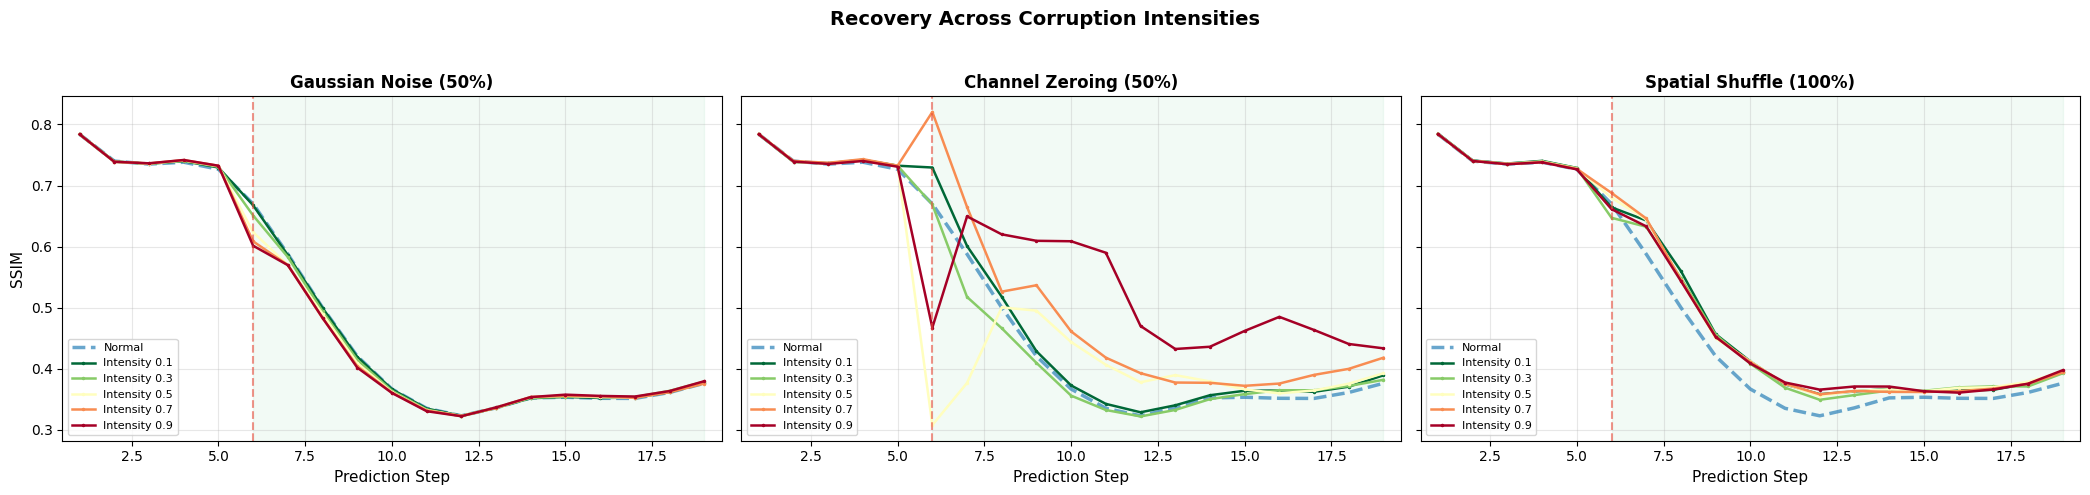

In [8]:
# === MULTI-INTENSITY SWEEP ===
intensities = [0.1, 0.3, 0.5, 0.7, 0.9]

# Use a larger batch for more stable statistics
np.random.seed(123)
sweep_indices = np.random.choice(len(data), BATCH_SIZE, replace=False)
sweep_batch = torch.from_numpy(data[sweep_indices]).float().to(device)
sweep_init = sweep_batch[:, 0].unsqueeze(1) / 255.0

sweep_results = {}  # {corruption_type: {intensity: ssim_curve}}

model.eval()
with torch.no_grad():
    # Normal baseline
    print("Running normal baseline...")
    normal_res = run_rollout_with_corruption(model, sweep_init, sweep_batch, corruption_type=None)
    normal_ssim_sweep = normal_res["ssim"].mean(dim=0).numpy()
    
    for ct in CORRUPTION_TYPES:
        sweep_results[ct] = {}
        for intensity in intensities:
            print(f"  {ct} @ intensity={intensity:.1f}...", end=" ")
            res = run_rollout_with_corruption(
                model, sweep_init, sweep_batch,
                corruption_type=ct, corruption_step=CORRUPTION_STEP, intensity=intensity)
            sweep_results[ct][intensity] = res["ssim"].mean(dim=0).numpy()
            print(f"final SSIM={sweep_results[ct][intensity][-1]:.4f}")

print("Sweep complete.")

# === PLOT ===
fig, axes = plt.subplots(1, len(CORRUPTION_TYPES), figsize=(7 * len(CORRUPTION_TYPES), 5),
                          sharey=True)
steps = np.arange(1, ROLLOUT_STEPS + 1)

cmap = plt.cm.RdYlGn_r  # Red for high intensity, green for low

for ax_idx, ct in enumerate(CORRUPTION_TYPES):
    ax = axes[ax_idx]
    
    # Normal baseline
    ax.plot(steps, normal_ssim_sweep, color='#2980B9', linewidth=2.5, 
            label='Normal', linestyle='--', alpha=0.7)
    
    for i, intensity in enumerate(intensities):
        color = cmap(i / (len(intensities) - 1))
        ax.plot(steps, sweep_results[ct][intensity], color=color, linewidth=1.8,
                label=f'Intensity {intensity:.1f}', marker='.', markersize=3)
    
    ax.axvline(x=CORRUPTION_STEP + 1, color='#E74C3C', linestyle='--', 
               linewidth=1.5, alpha=0.6)
    ax.axvspan(CORRUPTION_STEP + 1, ROLLOUT_STEPS, alpha=0.06, color='#27AE60')
    
    ax.set_xlabel('Prediction Step', fontsize=11)
    ax.set_title(CORRUPTION_LABELS[ct], fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.5, ROLLOUT_STEPS + 0.5)

axes[0].set_ylabel('SSIM', fontsize=11)

fig.suptitle('Recovery Across Corruption Intensities',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(save_dir / "fig_perturbation_sweep.pdf", dpi=300, bbox_inches='tight')
fig.savefig(save_dir / "fig_perturbation_sweep.png", dpi=200, bbox_inches='tight')
print(f"Saved to {save_dir / 'fig_perturbation_sweep.pdf'}")
print(f"Saved to {save_dir / 'fig_perturbation_sweep.png'}")
plt.show()

## Recovery time analysis (100 sequences)

Runs the corruption experiment on 100 sequences. Measures precise recovery time: steps after corruption before SSIM returns to within 90% of the normal rollout at the same step.

Expected mean recovery: 1-3 steps for noise/zero, 3-7 for shuffle. Std should be small (1-2 steps), indicating consistent self-repair.

What the numbers mean:
- **Mean < 3**: excellent. Laplacian diffusion dominates.
- **Mean 3-7**: good resilience, needs multiple evolve cycles.
- **Mean > 10 or many failures**: corruption overwhelms repair. Maybe stronger diffusion coefficient or more evolve steps would help?

In [9]:
# === RECOVERY TIME ANALYSIS: 100 SEQUENCES ===
N_ANALYSIS = 100
ANALYSIS_BATCH = 16

np.random.seed(7)
analysis_indices = np.random.choice(len(data), N_ANALYSIS, replace=False)

recovery_times = {ct: [] for ct in CORRUPTION_TYPES}
ssim_drops = {ct: [] for ct in CORRUPTION_TYPES}
final_ratios = {ct: [] for ct in CORRUPTION_TYPES}

n_batches = (N_ANALYSIS + ANALYSIS_BATCH - 1) // ANALYSIS_BATCH
t_start = time.time()

model.eval()
with torch.no_grad():
    for batch_idx in range(n_batches):
        start = batch_idx * ANALYSIS_BATCH
        end = min(start + ANALYSIS_BATCH, N_ANALYSIS)
        B_cur = end - start
        
        idx = analysis_indices[start:end]
        batch_data = torch.from_numpy(data[idx]).float().to(device)
        batch_init = batch_data[:, 0].unsqueeze(1) / 255.0
        
        # Normal baseline
        normal_res = run_rollout_with_corruption(
            model, batch_init, batch_data, corruption_type=None)
        normal_ssim_b = normal_res["ssim"]  # (B, 19)
        
        for ct in CORRUPTION_TYPES:
            corrupt_res = run_rollout_with_corruption(
                model, batch_init, batch_data,
                corruption_type=ct, corruption_step=CORRUPTION_STEP, intensity=0.5)
            corrupt_ssim_b = corrupt_res["ssim"]  # (B, 19)
            
            for b in range(B_cur):
                # SSIM drop
                if CORRUPTION_STEP > 0:
                    drop = corrupt_ssim_b[b, CORRUPTION_STEP - 1].item() - corrupt_ssim_b[b, CORRUPTION_STEP].item()
                else:
                    drop = 0.0
                ssim_drops[ct].append(drop)
                
                # Recovery time: first step >= 90% of normal
                rec_time = ROLLOUT_STEPS  # default: never recovered
                for t in range(CORRUPTION_STEP, ROLLOUT_STEPS):
                    n_val = normal_ssim_b[b, t].item()
                    c_val = corrupt_ssim_b[b, t].item()
                    if n_val > 0 and c_val >= 0.90 * n_val:
                        rec_time = t - CORRUPTION_STEP
                        break
                recovery_times[ct].append(rec_time)
                
                # Final ratio
                n_final = normal_ssim_b[b, -1].item()
                c_final = corrupt_ssim_b[b, -1].item()
                final_ratios[ct].append(c_final / n_final if n_final > 0 else 0.0)
        
        elapsed = time.time() - t_start
        print(f"  Batch {batch_idx+1}/{n_batches} ({end}/{N_ANALYSIS}) | {elapsed:.1f}s")

elapsed_total = time.time() - t_start
print(f"\nAnalysis complete: {N_ANALYSIS} sequences in {elapsed_total:.1f}s")

# === PRINT STATISTICS ===
print("\n" + "=" * 70)
print("RECOVERY TIME STATISTICS (steps to reach 90% of normal SSIM)")
print("=" * 70)

for ct in CORRUPTION_TYPES:
    rt = np.array(recovery_times[ct])
    drops = np.array(ssim_drops[ct])
    ratios = np.array(final_ratios[ct])
    
    n_recovered = np.sum(rt < ROLLOUT_STEPS)
    
    print(f"\n  {CORRUPTION_LABELS[ct]}:")
    print(f"    Recovery time:  mean={rt.mean():.2f}, median={np.median(rt):.1f}, std={rt.std():.2f}")
    print(f"    SSIM drop:      mean={drops.mean():.4f}, std={drops.std():.4f}")
    print(f"    Final ratio:    mean={ratios.mean():.2%}, std={ratios.std():.2%}")
    print(f"    Recovered:      {n_recovered}/{N_ANALYSIS} ({n_recovered/N_ANALYSIS:.0%})")
    
    if n_recovered == N_ANALYSIS:
        print(f"    --> FULL AUTOPOIESIS: every sequence self-repaired")
    elif n_recovered > 0.9 * N_ANALYSIS:
        print(f"    --> STRONG AUTOPOIESIS: >90% of sequences self-repaired")
    elif n_recovered > 0.5 * N_ANALYSIS:
        print(f"    --> PARTIAL AUTOPOIESIS: >50% of sequences self-repaired")
    else:
        print(f"    --> WEAK AUTOPOIESIS: <50% of sequences self-repaired")

print("\n" + "=" * 70)

  Batch 1/7 (16/100) | 8.7s
  Batch 2/7 (32/100) | 17.5s
  Batch 3/7 (48/100) | 26.3s
  Batch 4/7 (64/100) | 34.9s
  Batch 5/7 (80/100) | 43.4s
  Batch 6/7 (96/100) | 51.9s
  Batch 7/7 (100/100) | 59.7s

Analysis complete: 100 sequences in 59.7s

RECOVERY TIME STATISTICS (steps to reach 90% of normal SSIM)

  Gaussian Noise (50%):
    Recovery time:  mean=0.20, median=0.0, std=0.49
    SSIM drop:      mean=0.1017, std=0.0295
    Final ratio:    mean=100.24%, std=1.64%
    Recovered:      100/100 (100%)
    --> FULL AUTOPOIESIS: every sequence self-repaired

  Channel Zeroing (50%):
    Recovery time:  mean=0.74, median=0.0, std=1.08
    SSIM drop:      mean=0.1391, std=0.0878
    Final ratio:    mean=100.95%, std=9.86%
    Recovered:      100/100 (100%)
    --> FULL AUTOPOIESIS: every sequence self-repaired

  Spatial Shuffle (100%):
    Recovery time:  mean=0.09, median=0.0, std=0.29
    SSIM drop:      mean=0.0599, std=0.0459
    Final ratio:    mean=104.93%, std=5.45%
    Recovered:

## Save results

Saves everything to `experiments/analysis/perturbation_recovery_stats.npz`: recovery times, SSIM drops, final SSIM ratios, sweep curves.

Load with `np.load('perturbation_recovery_stats.npz', allow_pickle=True)`. The `config` item stores experimental parameters as a dictionary.

In [10]:
# === SAVE RESULTS ===
analysis_dir = PROJECT / "experiments" / "analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

save_dict = {
    # Recovery analysis (100 sequences)
    "recovery_times_noise": np.array(recovery_times["noise"]),
    "recovery_times_zero": np.array(recovery_times["zero"]),
    "recovery_times_shuffle": np.array(recovery_times["shuffle"]),
    "ssim_drops_noise": np.array(ssim_drops["noise"]),
    "ssim_drops_zero": np.array(ssim_drops["zero"]),
    "ssim_drops_shuffle": np.array(ssim_drops["shuffle"]),
    "final_ratios_noise": np.array(final_ratios["noise"]),
    "final_ratios_zero": np.array(final_ratios["zero"]),
    "final_ratios_shuffle": np.array(final_ratios["shuffle"]),
    # Sweep curves (per intensity)
    "sweep_intensities": np.array(intensities),
    "sweep_normal_ssim": normal_ssim_sweep,
}

for ct in CORRUPTION_TYPES:
    for intensity in intensities:
        key = f"sweep_{ct}_{str(intensity).replace('.', 'p')}"
        save_dict[key] = sweep_results[ct][intensity]

# Config metadata
save_dict["config"] = np.array({
    "corruption_step": CORRUPTION_STEP,
    "rollout_steps": ROLLOUT_STEPS,
    "n_analysis": N_ANALYSIS,
    "d_model": D_MODEL,
    "checkpoint": CHECKPOINT,
    "checkpoint_epoch": ckpt.get("epoch", "?"),
})

save_path = analysis_dir / "perturbation_recovery_stats.npz"
np.savez_compressed(save_path, **save_dict)

print(f"Results saved to: {save_path}")
print(f"File size: {save_path.stat().st_size / 1024:.1f} KB")
print(f"\nKeys: {list(save_dict.keys())}")

# === SUMMARY ===
print("\n" + "=" * 60)
print("PERTURBATION RECOVERY EXPERIMENT COMPLETE")
print("=" * 60)
print(f"")
print(f"Figures saved:")
print(f"  {save_dir / 'fig_perturbation_recovery.pdf'}")
print(f"  {save_dir / 'fig_perturbation_recovery.png'}")
print(f"  {save_dir / 'fig_perturbation_sweep.pdf'}")
print(f"  {save_dir / 'fig_perturbation_sweep.png'}")
print(f"")
print(f"Data saved:")
print(f"  {save_path}")
print(f"")
print(f"Key findings:")
for ct in CORRUPTION_TYPES:
    rt = np.array(recovery_times[ct])
    n_rec = np.sum(rt < ROLLOUT_STEPS)
    print(f"  {CORRUPTION_LABELS[ct]}: {n_rec}/{N_ANALYSIS} recovered, "
          f"mean time = {rt.mean():.1f} steps")

Results saved to: C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\experiments\analysis\perturbation_recovery_stats.npz
File size: 10.8 KB

Keys: ['recovery_times_noise', 'recovery_times_zero', 'recovery_times_shuffle', 'ssim_drops_noise', 'ssim_drops_zero', 'ssim_drops_shuffle', 'final_ratios_noise', 'final_ratios_zero', 'final_ratios_shuffle', 'sweep_intensities', 'sweep_normal_ssim', 'sweep_noise_0p1', 'sweep_noise_0p3', 'sweep_noise_0p5', 'sweep_noise_0p7', 'sweep_noise_0p9', 'sweep_zero_0p1', 'sweep_zero_0p3', 'sweep_zero_0p5', 'sweep_zero_0p7', 'sweep_zero_0p9', 'sweep_shuffle_0p1', 'sweep_shuffle_0p3', 'sweep_shuffle_0p5', 'sweep_shuffle_0p7', 'sweep_shuffle_0p9', 'config']

PERTURBATION RECOVERY EXPERIMENT COMPLETE

Figures saved:
  C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\paper\figures\fig_perturbation_recovery.pdf
  C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\paper\figures\fig_perturbation_recovery.png
  C:\DEV\Workspace\active\coding\_AI RESEAR